# FITTING NOTEBOOK

In [22]:
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import corner
import transitspectroscopy as ts
from tqdm import tqdm

import seaborn as sns
sns.set_style('ticks')

In [23]:
# Open data file (transitspectroscopy output)
path = '/media/peng/KINGSTON/'
with open(path + '_jw03385002001_toi1130_nrs2_spectrum.pkl', 'rb') as file:
    data = pickle.load(file)

# data is a dict with 7 entries: 
# 1. metadata: Information about instrument and detector, ex. name: NIRSpec, detector: NRS1
# 2. & 3. tso & tso_err: Not sure, just a bunch of zeroes as far as I can see
# 4. traces: Contains times in random order, x, ycorrected, ysmoothed
# 5 spectra: Contains times in increasing order, original + original_err, corrected + corrected_err, wavelength map (a bunch of nans) and wavelengths that the detector measures
# --> IMPORTANT: data['spectra']['corrected'] and corrected_err contain each spectroscopic lc for the corresponding wavelength in ppm (more detail in next section)
# 6 & 7. whitelight & whitelight_err: Relative flux for white light curve and its errorbars

In [24]:
# Define planetary parameters
per = 4.074554             # Period (Days)
t0 = 2460543.0635          # Mid-Transit Time (BJD)
a = 13.77                  # Semimajor Axis (a/R*)
b = -0.518                 # Impact Parameter
ecc = 0.052162             # Eccentricity
omega = 141.11             # Argument of Periastron (Degrees)

# Define planet and instrument name
star = 'TOI-1130'
pn = 'TOI-1130b'
itm = 'NRS2'

# White Light Curves

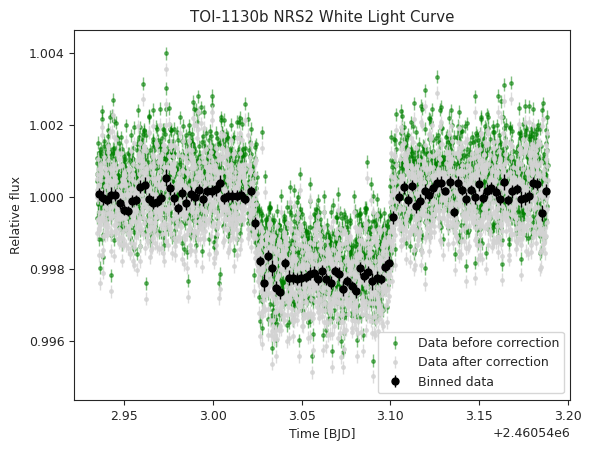

In [25]:
# Define time and flux data points
t = data['spectra']['times']
f_wl = data['whitelight']
ferr_wl = data['whitelight_err']

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'g', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data before correction', zorder = 1)

# Normalize flux such that the out-of-transit flux = 1
f_med = np.nanmedian(f_wl[:100])
f_wl, ferr_wl = f_wl / f_med, ferr_wl / f_med
tbin, fbin, ferrbin = juliet.bin_data(t, f_wl, 25)

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.8, label = 'Data after correction', zorder = 5)
plt.errorbar(tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned data', zorder = 10)

plt.title(pn+' '+itm+ ' White Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Relative flux')

# Define root-mean-squared values
rms = ts.utils.get_mad_sigma(np.median(f_wl[: 100] - 1.), f_wl[: 100] - 1.) * 1e6
rms_predicted = np.median(ferr_wl[: 100]) * 1e6

plt.legend()
plt.show()

In [26]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

In [27]:
# Define parameters - comment out all sets except for one

# # Just transit
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.]]
# #--------------------------------------------------------------------------------------------------

# Linear
params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
          'theta0_'+itm]

dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform']

hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
          [-10, 10]]
# #--------------------------------------------------------------------------------------------------

# # GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [1e-8, 1e2], [1e-8, 1e3]]
#--------------------------------------------------------------------------------------------------

# # Linear + GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'theta0_'+itm, 'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'uniform', 'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [-10, 10], [1e-6, 1e6], [1e-3, 1e3]]


priors = juliet.generate_priors(params, dists, hyperps) 

In [28]:
# Put data into dictionaries to feed into juliet
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_wl, ferr_wl
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler, again comment out everything except for the one you're running

# # Just transit
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  ld_laws = 'quadratic', out_folder = pn+'_fit_'+itm)
# #---------------------------------------------------------------------------------------------

# Linear
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_fit_'+itm+'_linear')
# #---------------------------------------------------------------------------------------------

# # GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_fit_'+itm+'_GP')
#---------------------------------------------------------------------------------------------

# # Linear + GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  linear_regressors_lc = linear_regressors, GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_fit_'+itm+'_L+GP')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_fit_NRS2_linear/_dynesty_DNS_posteriors.pkl
done


In [29]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_wl**2)

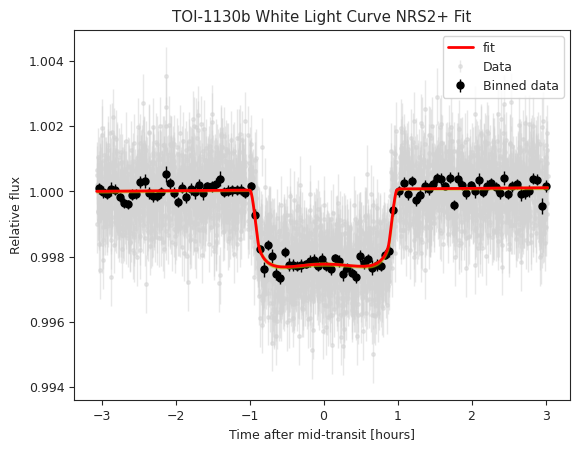

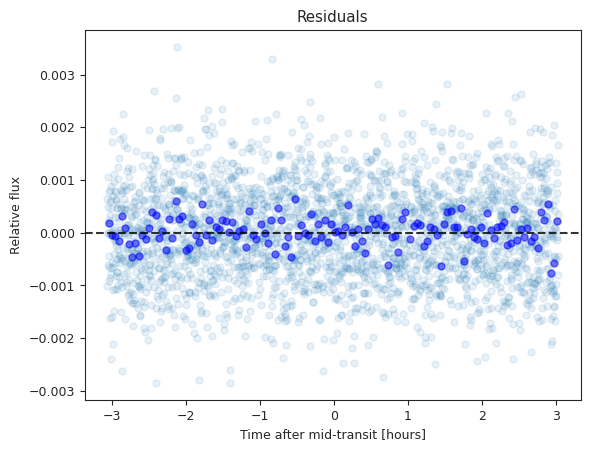

In [30]:
# Normalize time so that it's relative to best-fit mid-transit and make some plots
mid_t = np.median(results.posteriors['posterior_samples']['t0_p1'])
norm_t = (t - mid_t) * 24
norm_tbin = (tbin - mid_t) * 24

# Scatter data
plt.errorbar(norm_t, f_wl, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+' White Light Curve '+itm+'+ Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Relative flux')
plt.legend()
plt.show()

# Residuals plot
resid = f_wl - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Relative flux')
plt.show()

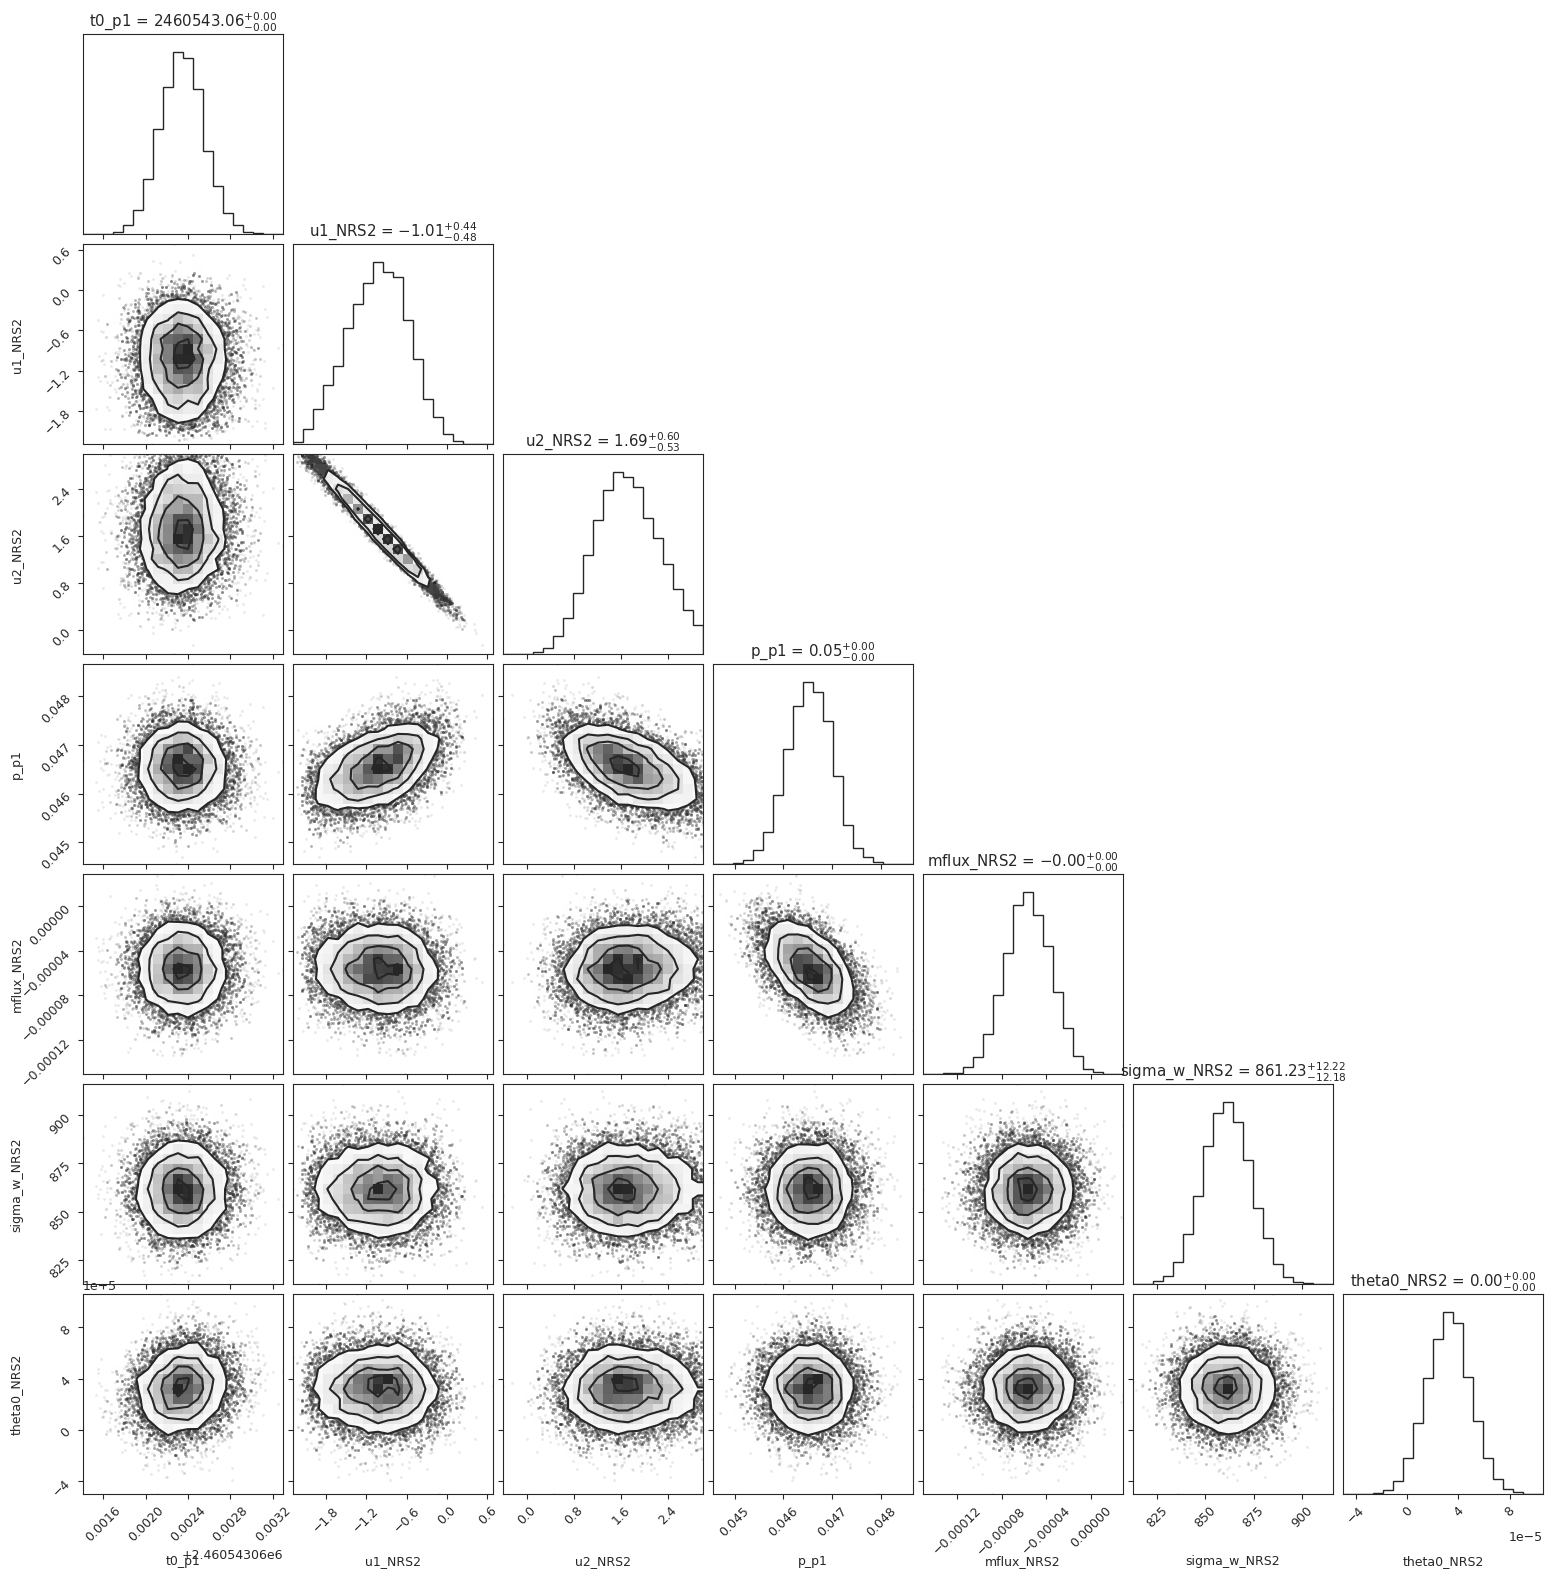

In [31]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles=True,)
plt.show()

In [32]:
# Print log evidence, lnZ
# print('Without linear or GP:', results.posteriors['lnZ'])
print('With linear only:', results.posteriors['lnZ'])
# print('With GP only:', results.posteriors['lnZ'])
# print('With linear + GP:', results.posteriors['lnZ'])

With linear only: 14972.623838445552


# Spectroscopic Light Curves

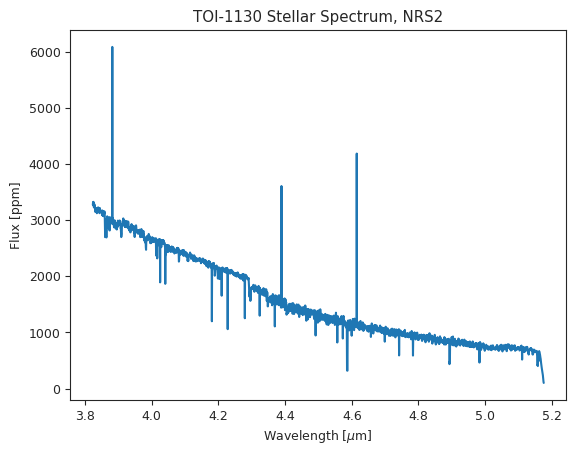

In [18]:
spectra = data['spectra']

# There are m times and n wavelengths
t = spectra['times']
wl = spectra['wavelengths']   

# Each spectra['corrected'] is a mxn array, where columns contain the corresponding spectroscopic light curve in ppm
slc, slc_err = spectra['corrected'], spectra['corrected_err']  

# We can plot corrected spectrum vs wavelength to see something that looks like the stellar spectrum
plt.plot(wl, slc[0])
plt.title(star+' Stellar Spectrum, '+itm)
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Flux [ppm]')
plt.show()

# To format slc and slc_err to give fluxes at each wavelength, index them along a column
# For example f[i] = slc[:, i] gives the ith spectroscopic light curve corresponding to the ith wavelength

In [19]:
print(slc)

[[3271.52919684 3316.36624203 3300.50427811 ...  163.45891788
   123.20167308  101.90437376]
 [3261.880805   3364.45892536 3294.87970978 ...  181.4450193
   131.75432002   96.87746216]
 [3245.00143497 3338.24132293 3321.64306197 ...  181.88230229
   125.87110421  101.99646031]
 ...
 [3250.06923384 3323.15825194 3276.03795447 ...  171.67289602
   128.79376175  112.21436698]
 [3253.35960211 3328.13936456 3313.48371753 ...  174.09011858
   127.69716529  102.8835168 ]
 [3226.14622537 3322.7651148  3350.47343204 ...  163.58085074
   131.13258516  105.5910846 ]]


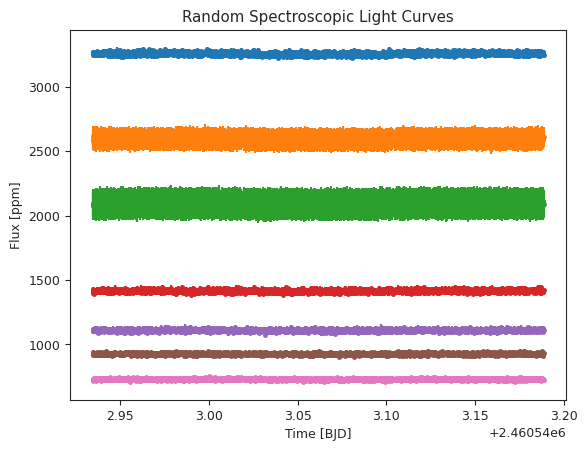

In [20]:
# Bin every 10 wavelengths and spectroscopic light curves
bin_slc, bin_slc_err = [] ,[]

for i in range(len(slc)):
    j, k, l = juliet.bin_data(wl, slc[i], 10)   # These are xbin, ybin, ybinerr for each column in slc
    bin_slc.append(k)
    bin_slc_err.append(l)
bin_wl = j     

# bin_wl is simply a list of all the binned wavelengths
# bin_slc and bin_slc_err are the same as slc and slc_err but now instead of mxn, they are mx(n/10) lists, again, where each column is a light curve
    
# # Plot binned stellar spectrum (for the last timestamp)
# plt.errorbar(j, k, yerr = l, fmt = '.')
# plt.title(star+' Binned Stellar Spectrum, NRS1')
# plt.xlabel('Wavelength [$\mu$m]')
# plt.ylabel('Flux [ppm]')
# plt.show()

# Plot random spectroscopic light curves, first turning lists into numpy arrays
bin_slc, bin_slc_err = np.array(bin_slc), np.array(bin_slc_err)

for i in range(0, len(bin_slc[0]), 30):
    plt.errorbar(t, bin_slc[:, i], yerr = bin_slc_err[:, i], fmt = '.')

plt.title('Random Spectroscopic Light Curves')
plt.xlabel('Time [BJD]')
plt.ylabel('Flux [ppm]')
plt.show()

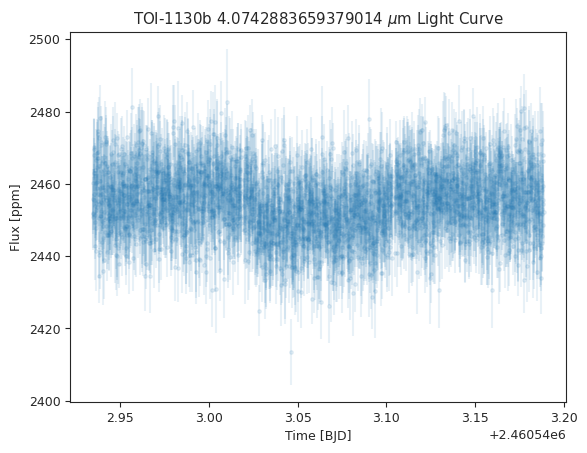

In [21]:
# Store all spectroscopic light curves in a dict, where each key is a wavelength whose value is another dict. In the nested dict, keys will be flux and flux error 
# --> spec_lcs = {wavelength 1: {flux: [...], err: [...]}, wavelength 2: {flux: [...], err: [...]}, ..., wavelength n: {flux: [...], err: [...]}}
# If you want to fit spectroscopic light curves to native resolutions, just call wl and slc instead of binned versions, then bin data points afterwards

spec_lcs = {}
for i in range(len(bin_wl)):
    wavelength = bin_wl[i]
    spec_lcs[wavelength] = {}
    spec_lcs[wavelength]['f'] = bin_slc[:, i]
    spec_lcs[wavelength]['ferr'] = bin_slc_err[:, i]

# For NRS1, pick a wavelength between 2.8 and 3.7 micron; for NRS2, between 3.8 and 5.2; for SOSS, between 0.6 and 2.8
# But run next cell for exact values
trial_wl = 4.0742883659379014
plt.errorbar(t, spec_lcs[trial_wl]['f'], yerr = spec_lcs[trial_wl]['ferr'], fmt = '.', alpha = 0.1)

plt.title(pn+' '+str(trial_wl)+' $\mu$m Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Flux [ppm]')
plt.show()

In [1]:
# for i in spec_lcs:
#     print(i)